# Random Forest 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer

In [2]:
# Cargar los datos
df_entrena = pd.read_csv('data/hoteles-entrena.csv')
df_prueba = pd.read_csv('data/hoteles-prueba.csv')

# Verificar las columnas no numéricas
print(df_entrena.select_dtypes(exclude=['float64', 'int64', 'uint8']).columns)
print(df_prueba.select_dtypes(exclude=['float64', 'int64', 'uint8']).columns)


Index(['hotel', 'children', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'required_car_parking_spaces',
       'arrival_date'],
      dtype='object')
Index(['hotel', 'meal', 'country', 'market_segment', 'distribution_channel',
       'reserved_room_type', 'assigned_room_type', 'deposit_type',
       'customer_type', 'required_car_parking_spaces', 'arrival_date'],
      dtype='object')


In [3]:
df_entrena.isna().sum().sort_values(ascending=False)
df_prueba.isna().sum().sort_values(ascending=False)

# Rellenar los valores faltantes
df_entrena['company'] = df_entrena['company'].fillna(0)
df_entrena['agent'] = df_entrena['agent'].fillna(0)
df_entrena['country'] = df_entrena['country'].fillna('Unknown')

df_prueba['company'] = df_prueba['company'].fillna(0)
df_prueba['agent'] = df_prueba['agent'].fillna(0)
df_prueba['country'] = df_prueba['country'].fillna('Unknown')


In [4]:
# Preprocesamiento de datos
df_entrena.dtypes
df_prueba.dtypes

id                                  int64
hotel                              object
lead_time                           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             float64
company                           float64
days_in_waiting_list                int64
customer_type                      object
average_daily_rate                float64
required_car_parking_spaces        object
total_of_special_requests         

In [5]:
# Lista de columnas categóricas
categorical_columns = ['hotel', 'meal', 'country', 'market_segment', 'distribution_channel', 
                       'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

# Aplicar One-Hot Encoding a las columnas categóricas
df_entrena_encoded = pd.get_dummies(df_entrena, columns=categorical_columns, drop_first=True)
df_prueba_encoded = pd.get_dummies(df_prueba, columns=categorical_columns, drop_first=True)

# Paso 3: Alinea las columnas del conjunto de prueba con las del conjunto de entrenamiento
df_prueba_encoded = df_prueba_encoded.reindex(columns=df_entrena_encoded.columns, fill_value=0)

# Verificar que ambos conjuntos tienen las mismas columnas
print(df_entrena_encoded.shape)
print(df_prueba_encoded.shape)

# Mostrar las primeras filas del DataFrame transformado para verificar
print(df_entrena_encoded.head())
print(df_prueba_encoded.head())

(52981, 199)
(22185, 199)
   lead_time  stays_in_weekend_nights  stays_in_week_nights  adults children  \
0        342                        0                     0       2     none   
1        737                        0                     0       2     none   
2          7                        0                     1       1     none   
3         13                        0                     1       1     none   
4         14                        0                     2       2     none   

   is_repeated_guest  previous_cancellations  previous_bookings_not_canceled  \
0                  0                       0                               0   
1                  0                       0                               0   
2                  0                       0                               0   
3                  0                       0                               0   
4                  0                       0                               0   

   booking_c

In [6]:
print(df_entrena_encoded["children"].value_counts()) 
print(df_prueba_encoded["children"].value_counts())


none        48647
children     4334
Name: children, dtype: int64
0    22185
Name: children, dtype: int64


In [7]:
# Reemplazar los valores de texto en la columna "children"
df_entrena_encoded['children'] = df_entrena_encoded['children'].replace({'none': 0, 'children': 1})

# Convertir la columna a numérico para asegurar que todo esté en formato correcto
df_entrena_encoded['children'] = pd.to_numeric(df_entrena_encoded['children'], errors='coerce')

# Eliminar la columna "children" del conjunto de prueba
df_prueba_encoded = df_prueba_encoded.drop(columns=['children'])

# Verificar los cambios en el conjunto de entrenamiento
print(df_entrena_encoded['children'].value_counts())





0    48647
1     4334
Name: children, dtype: int64


In [8]:
print(df_entrena_encoded.dtypes)
print(df_prueba_encoded.dtypes)

lead_time                        int64
stays_in_weekend_nights          int64
stays_in_week_nights             int64
adults                           int64
children                         int64
                                 ...  
deposit_type_Non_Refund          uint8
deposit_type_Refundable          uint8
customer_type_Group              uint8
customer_type_Transient          uint8
customer_type_Transient-Party    uint8
Length: 199, dtype: object
lead_time                        int64
stays_in_weekend_nights          int64
stays_in_week_nights             int64
adults                           int64
is_repeated_guest                int64
                                 ...  
deposit_type_Non_Refund          uint8
deposit_type_Refundable          uint8
customer_type_Group              uint8
customer_type_Transient          uint8
customer_type_Transient-Party    uint8
Length: 198, dtype: object


In [9]:
# Reemplazar el valor 'none' por 0 en la columna 'required_car_parking_spaces'
df_entrena_encoded['required_car_parking_spaces'] = df_entrena_encoded['required_car_parking_spaces'].replace('none', 0)
df_prueba_encoded['required_car_parking_spaces'] = df_prueba_encoded['required_car_parking_spaces'].replace('none', 0)

# Convertir la columna a numérico
df_entrena_encoded['required_car_parking_spaces'] = pd.to_numeric(df_entrena_encoded['required_car_parking_spaces'], errors='coerce')
df_prueba_encoded['required_car_parking_spaces'] = pd.to_numeric(df_prueba_encoded['required_car_parking_spaces'], errors='coerce')




In [10]:
# Verificar si alguna columna tiene valores no numéricos
for column in df_entrena_encoded.columns:
    if df_entrena_encoded[column].dtype == 'object':  # Verificamos solo las columnas de tipo 'object'
        print(f"{column} tiene valores no numéricos:")
        print(df_entrena_encoded[column].apply(lambda x: isinstance(x, str)).value_counts())


arrival_date tiene valores no numéricos:
True    52981
Name: arrival_date, dtype: int64


In [11]:
# Convertir la columna 'arrival_date' a formato datetime
df_entrena_encoded['arrival_date'] = pd.to_datetime(df_entrena_encoded['arrival_date'], errors='coerce')

# Extraer características relevantes de la fecha
df_entrena_encoded['arrival_year'] = df_entrena_encoded['arrival_date'].dt.year
df_entrena_encoded['arrival_month'] = df_entrena_encoded['arrival_date'].dt.month
df_entrena_encoded['arrival_day_of_week'] = df_entrena_encoded['arrival_date'].dt.dayofweek

# Eliminar la columna 'arrival_date' original si ya no es necesaria
df_entrena_encoded = df_entrena_encoded.drop(columns=['arrival_date'])

# Repetir el proceso para el conjunto de prueba
df_prueba_encoded['arrival_date'] = pd.to_datetime(df_prueba_encoded['arrival_date'], errors='coerce')
df_prueba_encoded['arrival_year'] = df_prueba_encoded['arrival_date'].dt.year
df_prueba_encoded['arrival_month'] = df_prueba_encoded['arrival_date'].dt.month
df_prueba_encoded['arrival_day_of_week'] = df_prueba_encoded['arrival_date'].dt.dayofweek
df_prueba_encoded = df_prueba_encoded.drop(columns=['arrival_date'])


In [12]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score



In [13]:
X = df_entrena_encoded.drop(columns=['children'])  # Características (sin la columna objetivo)
y = df_entrena_encoded['children']  # Variable objetivo


In [14]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [16]:
from sklearn.impute import SimpleImputer
# Crear un objeto imputador para las columnas numéricas (rellenar con la media)
imputer = SimpleImputer(strategy='mean')

# Imputar los valores faltantes en el conjunto de entrenamiento
X_train_imputed = imputer.fit_transform(X_train)

# También imputar los valores en el conjunto de validación
X_val_imputed = imputer.transform(X_val)


In [21]:
from imblearn.over_sampling import SMOTE

# Crear el objeto SMOTE
smote = SMOTE(random_state=42)

# Aplicar SMOTE al conjunto de entrenamiento imputado (sin valores faltantes)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_imputed, y_train)

# Convertir X_train_resampled de vuelta a un DataFrame
X_train_resampled = pd.DataFrame(X_train_resampled, columns=X_train.columns)

# Hacer lo mismo con X_val_imputed si no es un DataFrame
X_val_imputed = pd.DataFrame(X_val_imputed, columns=X_val.columns)



In [22]:
from sklearn.preprocessing import StandardScaler

numeric_features = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 
                    'adults', 'is_repeated_guest', 'previous_cancellations', 
                    'previous_bookings_not_canceled', 'booking_changes', 
                    'company', 'agent', 'days_in_waiting_list', 
                    'required_car_parking_spaces', 'total_of_special_requests', 
                    'average_daily_rate']


# Crear el objeto StandardScaler
scaler = StandardScaler()

# Estandarizar el conjunto de entrenamiento
X_train_resampled[numeric_features] = scaler.fit_transform(X_train_resampled[numeric_features])

# Estandarizar el conjunto de validación (sin volver a ajustar el escalador)
X_val_imputed[numeric_features] = scaler.transform(X_val_imputed[numeric_features])


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Inicializar el modelo de Random Forest
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)

# Realizar validación cruzada (5 folds)
cv_scores = cross_val_score(rf_model, X_train_resampled, y_train_resampled, cv=5, scoring='accuracy')

# Mostrar los resultados de la validación cruzada
print("CV Accuracy Scores: ", cv_scores)
print("Mean CV Accuracy: ", cv_scores.mean())


CV Accuracy Scores:  [0.85417871 0.9941543  0.99505364 0.99421854 0.99357574]
Mean CV Accuracy:  0.9662361864937624


In [28]:
from sklearn.model_selection import GridSearchCV

# Configurar GridSearchCV en lugar de RandomizedSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Ajustar el modelo
grid_search.fit(X_train_resampled, y_train_resampled)

# Ver los mejores hiperparámetros encontrados
print("Best Parameters: ", grid_search.best_params_)
print("Best Score: ", grid_search.best_score_)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=5, min_samples_split=10, n_estimators=50; total time=  13.4s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=5, min_samples_split=10, n_estimators=50; total time=  13.8s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=5, min_samples_split=10, n_estimators=50; total time=  14.6s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=5, min_samples_split=10, n_estimators=50; total time=  14.6s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=5, min_samples_split=10, n_estimators=50; total time=  15.1s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=5, min_samples_split=10, n_estimators=100; total time=  29.1s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=5, min_samples_split=10, n_estimators=100; total time=  29.7s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=5, min_samples_split=10, n_estimators=100; total time=  29.9s
[

In [29]:
# Obtener el mejor modelo encontrado por GridSearch
best_rf_model = grid_search.best_estimator_

# Hacer predicciones sobre el conjunto de validación
y_pred = best_rf_model.predict(X_val_imputed)

# Evaluar el rendimiento del modelo
from sklearn.metrics import accuracy_score, classification_report

# Calcular y mostrar la precisión
accuracy = accuracy_score(y_val, y_pred)
print("Validation Accuracy: ", accuracy)

# Mostrar un informe detallado de las métricas del modelo
print(classification_report(y_val, y_pred))


Validation Accuracy:  0.9382844201189016
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      9730
           1       0.70      0.42      0.53       867

    accuracy                           0.94     10597
   macro avg       0.83      0.70      0.75     10597
weighted avg       0.93      0.94      0.93     10597



In [30]:
# Hacer predicciones sobre el conjunto de prueba final
y_test_pred = best_rf_model.predict(df_prueba_encoded)

# Mostrar las predicciones finales
print(y_test_pred)


[1 1 1 ... 1 1 1]


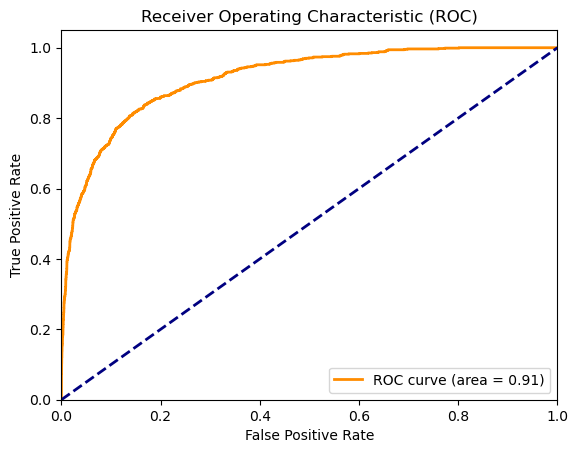

AUC: 0.9133468706991894


In [31]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Obtener las probabilidades predichas para la clase 1 (niños)
y_pred_proba = best_rf_model.predict_proba(X_val_imputed)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)

# Calcular el AUC
roc_auc = roc_auc_score(y_val, y_pred_proba)

# Graficar la curva ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Línea diagonal para referencia
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# Mostrar el AUC
print(f"AUC: {roc_auc}")
